## Fashion MNIST CNN 학습

- 기존 로지스틱 회귀를 CNN으로 변경

### 1. 라이브러리 로드

In [43]:
# 라이브러리 로드
import torch
import torchvision  # 컴퓨터비젼 모듈
import torchvision.transforms as transforms # 데이터 변환

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [126]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # sm_120 의미 12.0 버전

2.12.0+cu130
13.0
NVIDIA GeForce RTX 5060
(12, 0)


### 2. 데이터전처리

In [45]:
# 데이터전처리(Transform) 정의
transform = transforms.Compose([
    # 이미지를 Tensor 형태로 변환
    transforms.ToTensor(),
    # 정규화, 0~1 범위값을 -1~1 범위로 변경
    transforms.Normalize((0.5,), (0.5,))
])

### 3. FashionMNIST 데이터셋 다운로드(학습데이터/테스트데이터)

In [46]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 학습용 데이터셋 사용여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform적용
    transform=transform
)

In [47]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 4. 데이터셋을 학습 데이터로더로 변경

In [48]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,
    # 데이터를 매 epoch 마다 데이터 섞음
    shuffle=True
)

In [49]:
train_loader

### 5. 테스트 데이터셋 다운로드

In [50]:
test_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 테스트 데이터
    train=False,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform적용
    transform=transform
)

In [51]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 6. 테스트 데이터로더 생성

In [52]:
test_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    test_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,
    # 테스트 데이터는 섞을 필요없음
    shuffle=False
)

In [53]:
test_loader

### 7. PyTorch GPU 사용가능 여부확인
- Compute Unified Device Architecture : NVIDIA가 제공하는 GPU 병렬컴퓨팅 플랫폼

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
f'Device : {device}'

'Device : cuda'

### 8. FashionMNIST 클래스(분류) 이름 지정

In [55]:
classes = [
    'T-shirt/top', # 티셔츠
    'Trouser', # 바지
    'Pullover', # 풀오버
    'Dress', # 드레스
    'Coat', # 코드
    'Sandal',  # 샌들
    'Shirt', # 셔츠
    'Sneaker', # 스니커즈
    'Bag',  # 가방
    'Ankle boot', # 발목부츠
]

Tensor shape : torch.Size([1, 28, 28])
Label : 1
Class name : Trouser


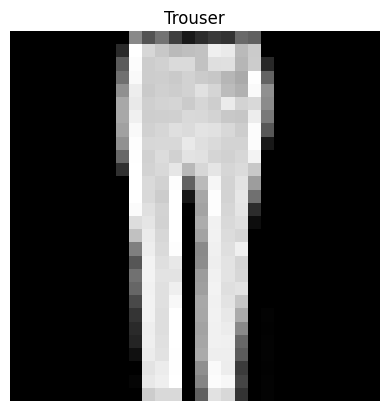

In [57]:
# 데이터셋에서 첫번째 데이터 
image, label = train_dataset[129]

print(f'Tensor shape : {image.shape}')
print(f'Label : {label}')
print(f'Class name : {classes[label]}')

# 정규화 복원
# 현재범위가 -1~1 범위로 정규화한걸 다시 복원
# 필요없음(x) - 옵션
image = image * 0.5 + 0.5

# 이미지 출력
# [1, 28, 28] -> [28, 28]
image = image.squeeze()  # 1차원 제거

plt.imshow(image, cmap='gray')
plt.title(classes[label])
plt.axis('off')
plt.show()

### 10. CNN 모델 클래스 선언

- CNN 사용

In [111]:
# CNN 모델 클래스
class CNN(nn.Module):
    def __init__(self):
        super().__init__()        
        # 1. 특징추출
        self.features = nn.Sequential(
            ## 첫번째 합성곱
            # batch size = 64
            # 입력이미지 : [batch, 1, 28, 28]
            # 합성곱 결과 : [batch, 32, 28, 28]
            # padding=1 을 안넣으면 [batch, 32, 26, 26] 으로 변경
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3, # 3x3
                # padding=1  # 1픽셀 여백추가
            ),
            nn.ReLU(), # 활성화함수 통과
            # 이미지크기 절반 축소
            # [batch, 32, 28, 28] -> [batch, 32, 14, 14]
            # [batch, 32, 26, 26] -> [batch, 32, 13, 13]
            nn.MaxPool2d(kernel_size=2, stride=2),

            ## 두번째 합성곱
            # [batch, 32, 14, 14] -> [batch, 64, 14, 14]
            # [batch, 32, 13, 13] -> [batch, 64, 11, 11]
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                # padding=1
            ),
            nn.ReLU(),  # 활성화함수 통과
            # 이미지크기 절반 축소
            # [batch, 64, 14, 14] -> [batch, 64, 7, 7]
            # [batch, 64, 11, 11] -> [batch, 64, 5, 5]
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 2. 분류
        self.classifier = nn.Sequential(
            # 3차원 특징맵을 1차원 벡터 변환
            # [batch, 64, 7, 7] -> [batch, 64*7*7(3136)]
            # [batch, 64, 5, 5] -> [batch, 64*5*5(1600)]
            nn.Flatten(), 
            # 완전연결층 생성
            # nn.Linear(64*7*7, 128),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            # 과적합 방지
            nn.Dropout(0.3), 
            # 최종 출력층
            # FashionMNIST 10개 클래스
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # 이미지 특징추출
        x = self.features(x)
        # 분류
        return self.classifier(x)

### 11. 모델 객체 생성

In [112]:
model = CNN().to(device)

In [113]:
model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 12. 손실함수 정의

In [106]:
# 다중클래스 분류에 사용하는 손실함수
loss_fn = nn.CrossEntropyLoss()

### 13. 최적화 알고리즘 정의

- Adam

In [107]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### 14. 모델 학습

In [89]:
num_epochs = 30

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader: # 64번 반복
        # GPU로 이동
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산 
        outputs = model(images) 

        # 손실계산        
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이터
        optimizer.step()
        
        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1}/{num_epochs}] Loss : {avg_loss:.4f}')

[Epoch 1/30] Loss : 0.1107
[Epoch 2/30] Loss : 0.1063
[Epoch 3/30] Loss : 0.0987
[Epoch 4/30] Loss : 0.0925
[Epoch 5/30] Loss : 0.0870
[Epoch 6/30] Loss : 0.0854
[Epoch 7/30] Loss : 0.0820
[Epoch 8/30] Loss : 0.0764
[Epoch 9/30] Loss : 0.0721
[Epoch 10/30] Loss : 0.0734
[Epoch 11/30] Loss : 0.0686
[Epoch 12/30] Loss : 0.0684
[Epoch 13/30] Loss : 0.0657
[Epoch 14/30] Loss : 0.0607
[Epoch 15/30] Loss : 0.0611
[Epoch 16/30] Loss : 0.0592
[Epoch 17/30] Loss : 0.0585
[Epoch 18/30] Loss : 0.0569
[Epoch 19/30] Loss : 0.0542
[Epoch 20/30] Loss : 0.0542
[Epoch 21/30] Loss : 0.0528
[Epoch 22/30] Loss : 0.0499
[Epoch 23/30] Loss : 0.0497
[Epoch 24/30] Loss : 0.0509
[Epoch 25/30] Loss : 0.0494
[Epoch 26/30] Loss : 0.0461
[Epoch 27/30] Loss : 0.0463
[Epoch 28/30] Loss : 0.0474
[Epoch 29/30] Loss : 0.0444
[Epoch 30/30] Loss : 0.0456


### 15. 모델 평가(테스트)

In [33]:
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [135]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 예측
        outputs = model(images)

        # 가장 높은 확률 선택
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

accuracy = 100 * (correct / total)

print(f'\n테스트 정확도 : {accuracy:.2f}%')


테스트 정확도 : 91.41%


### 16. 마지막 예측 테스트

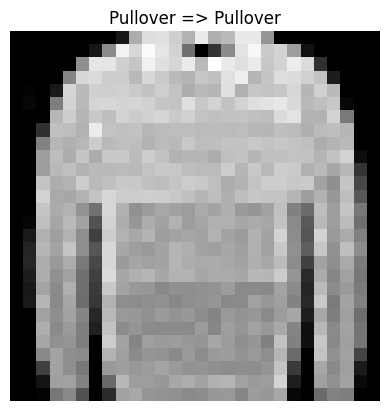

실제 답 : Pullover 예측결과 : Pullover


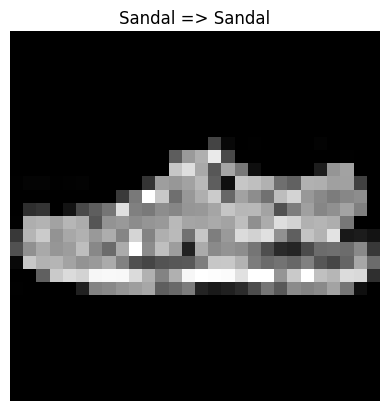

실제 답 : Sandal 예측결과 : Sandal


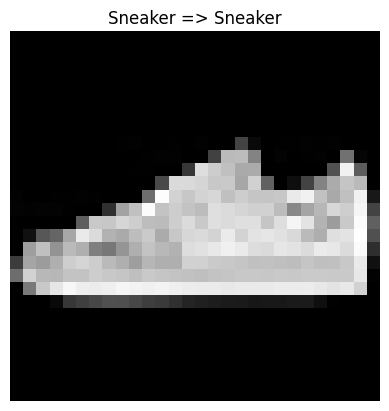

실제 답 : Sneaker 예측결과 : Sneaker


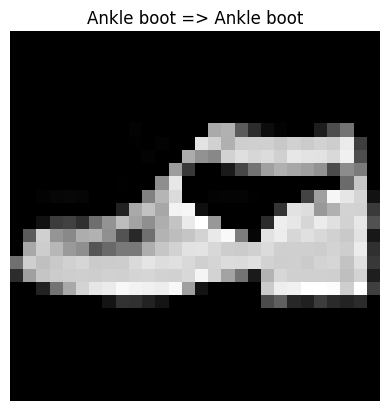

실제 답 : Ankle boot 예측결과 : Ankle boot


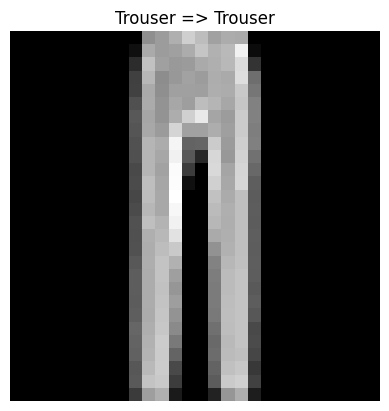

실제 답 : Trouser 예측결과 : Trouser


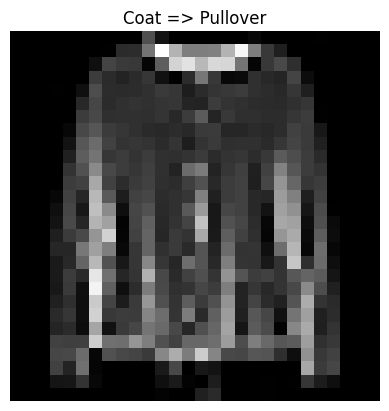

실제 답 : Coat 예측결과 : Pullover


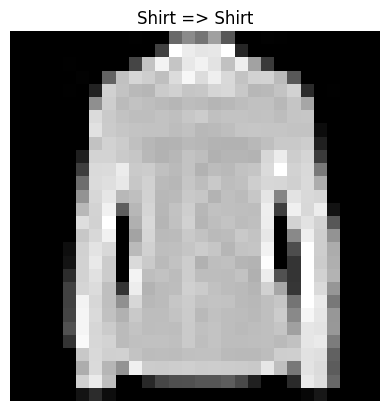

실제 답 : Shirt 예측결과 : Shirt


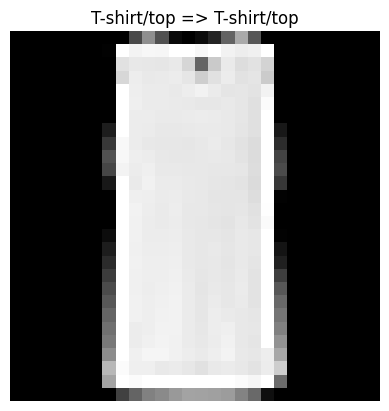

실제 답 : T-shirt/top 예측결과 : T-shirt/top


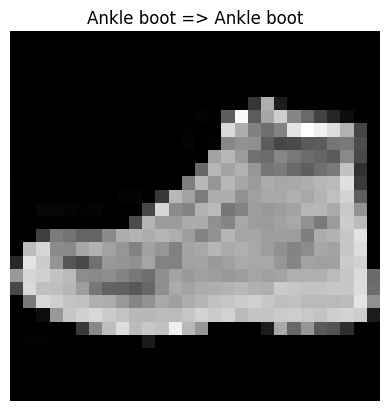

실제 답 : Ankle boot 예측결과 : Ankle boot


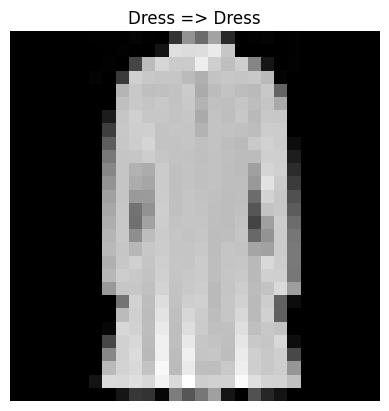

실제 답 : Dress 예측결과 : Dress


In [79]:
for i in range(20, 30):
    image, label = test_dataset[i]

    with torch.no_grad():
        # 차원 추가
        test_input = image.unsqueeze(0).to(device)

        # 출력
        output = model(test_input)

        predicted = torch.argmax(output, dim=1).item()

        plt.imshow(image.squeeze(), cmap='gray')
        # plt.figure(figsize=(28, 28))
        plt.title(f'{classes[label]} => {classes[predicted]}')
        plt.axis('off')
        plt.show()

    print(f'실제 답 : {classes[label]} 예측결과 : {classes[predicted]}')

### 17. 모델저장

In [90]:
torch.save(model.state_dict(), 'fashionMNIST_cnn.pth')

### 18. 모델 성능 끌어올리기

- 데이터 증강 추가
- CNN 모델 성능 올리기
- 최적화알고리즘 변경
- 학습횟수 epoch 증가

In [127]:
# 1. 데이터 증강 추가 - 학습용 트랜스폼 변경
train_transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5),   # 좌우반전
    transforms.RandomRotation(5), # 회전
    # transforms.RandomAffine(
    #     degrees=0,
    #     translate=(0.1, 0.1)  # 이동
    # ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [128]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 학습용 데이터셋 사용여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform적용
    transform=train_transform
)

In [130]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [129]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,
    # 데이터를 매 epoch 마다 데이터 섞음
    shuffle=True
)

In [ ]:
# 2. CNN 모델 성능 올리기
## 포기 - 원래모델로 돌려서 사용
class CNN(nn.Module):
    def __init__(self):
        super().__init__()        
        # 1. 특징추출
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            # nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64*7*7
        )

        # 2. 분류
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [132]:
model = CNN().to(device)
model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [133]:
# 3. 최적화 알고리즘 변경
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

In [134]:
# 4. 학습회수 증가 epoch을 10회 이상 
num_epochs = 15

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader: # 64번 반복
        # GPU로 이동
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산 
        outputs = model(images) 

        # 손실계산        
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이터
        optimizer.step()
        
        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1}/{num_epochs}] Loss : {avg_loss:.4f}')

[Epoch 1/15] Loss : 0.4512
[Epoch 2/15] Loss : 0.3036
[Epoch 3/15] Loss : 0.2650
[Epoch 4/15] Loss : 0.2418
[Epoch 5/15] Loss : 0.2237
[Epoch 6/15] Loss : 0.2095
[Epoch 7/15] Loss : 0.1983
[Epoch 8/15] Loss : 0.1861
[Epoch 9/15] Loss : 0.1786
[Epoch 10/15] Loss : 0.1721
[Epoch 11/15] Loss : 0.1608
[Epoch 12/15] Loss : 0.1550
[Epoch 13/15] Loss : 0.1525
[Epoch 14/15] Loss : 0.1454
[Epoch 15/15] Loss : 0.1387


- Loss가 0.2에서 0.1 사이로 나오는게 가장 좋음
- ex) 0.05 과적합!